# Homework 1: Social Network Analysis

In [1]:
import numpy as np
import scipy.sparse as ssp
from graphLib import Graph
from itertools import combinations
import matplotlib.pyplot as plt

## Example

In [3]:
#--- read the graph file and construct a graph
graph = Graph(ssp.load_npz('../data/example_graph.npz'))

In [8]:
# number of nodes in graph:
n = graph.n
print(n)

10


In [9]:
# get the adjacency matrix of graph

A = graph.get_adj_matrix()
print(A)

[[0 0 0 0 1 0 1 1 0 0]
 [0 0 1 0 0 0 0 0 1 0]
 [0 1 0 0 0 1 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [1 0 0 1 0 1 1 0 0 1]
 [0 0 1 0 1 0 0 0 0 0]
 [1 0 1 0 1 0 0 1 0 1]
 [1 0 0 0 0 0 1 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 1 0 0]]


In [5]:
# get adjacency list

adj_list = graph.get_adj_list()
for i in range(n):
	print(i, adj_list[i])

0 [np.int64(4), np.int64(6), np.int64(7)]
1 [np.int64(2), np.int64(8)]
2 [np.int64(1), np.int64(5), np.int64(6)]
3 [np.int64(4)]
4 [np.int64(0), np.int64(3), np.int64(5), np.int64(6), np.int64(9)]
5 [np.int64(2), np.int64(4)]
6 [np.int64(0), np.int64(2), np.int64(4), np.int64(7), np.int64(9)]
7 [np.int64(0), np.int64(6), np.int64(9)]
8 [np.int64(1)]
9 [np.int64(4), np.int64(6), np.int64(7)]


In [6]:
# get degree sequence

deg_seq = graph.get_deg_seq()
print(deg_seq)

[3 2 3 1 5 2 5 3 1 3]


## Task 1: Compute Graph Properties [45 points]

In [4]:
from task_1 import compute_deg_distr, get_cc_local, get_cc_global, get_diameter

### Task 1.1: Degree Distribution

In [55]:
#--- read the graph file and construct a graph
graph = Graph(ssp.load_npz('../data/graph_ER.npz'))

In [26]:
#--- obtain degree sequence and associated counts
degs,counts=compute_deg_distr(graph)

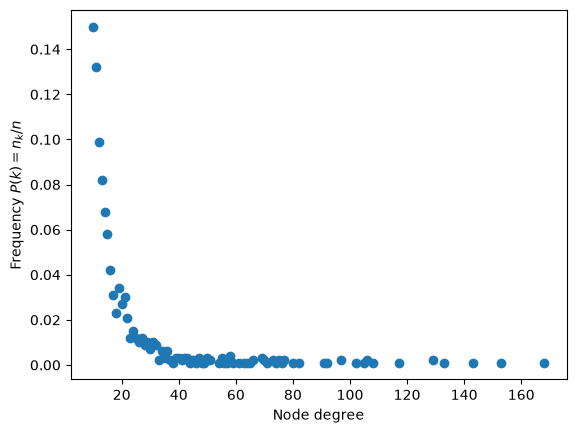

In [27]:
#--- plot the degree distribution

x = degs
y = counts/graph.n
plt.plot(x,y,'o')
plt.xlabel('Node degree')
plt.ylabel('Frequency $P(k) = n_k/n$')
plt.show()

### Task 1.2: Clustering Coefficients

In [56]:
for i in [0, 11, 24, 50, 150, 250, 334, 668]:
    print(get_cc_local(graph,i))

0.30111646446469686
0.3004475463811833
0.2996539792387543
0.2991234689731236
0.29529780564263325
0.30002986114567265
0.2964692389612517
0.2992534660504799


In [29]:
cc_global = get_cc_global(graph)

In [30]:
print(cc_global)

0.056632348530516616


### Task 1.3: Graph Diameter

In [37]:
diameter = get_diameter(graph)

In [38]:
print(diameter)

2


## Task 2: Compute Node Centralities [35 points]

In [39]:
from task_2 import get_eigen_centrality, build_matrix, get_btw_c

### Task 2.1: Eigenvector Centrality

In [5]:
# TODO: find the top-10 nodes and their eigenvector centralities

In [58]:
eigenvector = get_eigen_centrality(graph)

### Task 2.2: Betweenness Centrality

In [59]:
# build 2 global matrices: a distance matrix, and a matrix storing the number of shortest pathes
n = graph.n
distance_mat = np.zeros((n,n), dtype = int)
num_shortest_path_mat = np.zeros((n,n), dtype = int)

In [60]:
# construct the two matrices - it is recommended you save the two matrices into files since they 
# take a lot of time to compute 
build_matrix(graph,distance_mat,num_shortest_path_mat)

In [61]:
print(n)

# TODO: compute the betweenness centrality for each node
btw_c = np.zeros(n, dtype=float)
for i in range(n):
    btw_c[i] = get_btw_c(graph, i, distance_mat, num_shortest_path_mat)
    print(i)
    print(btw_c[i])

# top 10 nodes
top_10 = np.argsort(btw_c)[::-1][:10]
print(top_10)

# top 10 with centralities
for rank, node in enumerate(top_10, 1):
    print(rank, int(node), btw_c[node])

1000
0
0.0008088921253909756
1
0.0007917097109968027
2
0.0005382023545872969
3
0.0007451898662854804
4
0.0006835992552451906
5
0.0005912577003091227
6
0.0006801629563334668
7
0.0006014636862552164
8
0.0007084340825943749
9
0.0006886764845308272
10
0.0006636224528804486
11
0.0007865648522822114
12
0.000618569397649328
13
0.0007042155811920459
14
0.0005967261682545392
15
0.0006246768946849214
16
0.000879116330910124
17
0.0007078832494657801
18
0.0007674636629141296
19
0.0008279286551365772
20
0.0007174232147082147
21
0.0006243509664990467
22
0.0007917132126165354
23
0.0006959156164592925
24
0.000655938441347304
25
0.0006340585966184973
26
0.000660750970052407
27
0.0006705660373676714
28
0.0006489277927968016
29
0.0007370968152579906
30
0.0007984038570288098
31
0.0006309947777197786
32
0.000846298998468866
33
0.000652108290077906
34
0.000732644230809406
35
0.0007498378785514569
36
0.0008447004382172804
37
0.0008021002239722632
38
0.0006996430126624983
39
0.0006707339233856716
40
0.0007036

In [62]:
print(n)

eig_c = get_eigen_centrality(graph)

top_10 = np.argsort(eig_c)[::-1][:10]
print(top_10)

# top 10 with centralities
for rank, node in enumerate(top_10, 1):
    print(rank, int(node), eig_c[node])

1000
[538 708 997 832 482 762 814  16 217 148]
1 538 0.036552515353734376
2 708 0.03619288023954852
3 997 0.0361548069832417
4 832 0.03563936454024782
5 482 0.035596284283696204
6 762 0.03551095054775445
7 814 0.035415546734330956
8 16 0.035319714820426715
9 217 0.035298926648359916
10 148 0.03528940164786859


In [46]:
# compute centrality for node 0 (this is just an example)
centrality = get_btw_c(graph,5,distance_mat,num_shortest_path_mat)

## Task 3: Link Prediction [20 points]

In [63]:
from task_3 import gen_net_obs, compute_Jaccard, compute_Katz, link_pred

graph = Graph(ssp.load_npz('../data/ws_graph.npz'))

# load the test edges and non_edges
test_edges = np.loadtxt('../data/target.edges',dtype = int)
test_non_edges = np.loadtxt('../data/target.nonedges', dtype = int)
pos_num = len(test_edges)
neg_num = len(test_non_edges)

# 1 denotes an edge; 0 denotes a non-edge
ground_truth = np.concatenate((np.ones(pos_num,dtype = int),np.zeros(neg_num,dtype = int)), axis = 0)

In [ ]:
# TODO: generate observed network

In [64]:
adj_obs, test_set = gen_net_obs(graph, test_edges,test_non_edges)

In [ ]:
# TODO: Get similarity based on metric (Katz or Jaccard)

In [68]:
jaccardsim = compute_Jaccard(adj_obs,test_set)
np.savetxt('../result/Jac_sim.txt', jaccardsim, fmt = '%f')

In [66]:
katzsim = compute_Katz(adj_obs,test_set)
np.savetxt('../result/Katz_sim.txt', katzsim, fmt = '%f')

In [ ]:
# TODO: make prediction

In [67]:
pred_jac=link_pred(adj_obs, test_set, 'Jaccard',0.1)
pred_katz=link_pred(adj_obs, test_set, 'Katz',0.02)

In [70]:
# TODO: compute accuracy based on pred and groundtruth
# accuracy  =  correctly predicted node pairs/total number of pairs

# just take the fraction of rows where our prediction was correct
acc_jac = np.mean(pred_jac == ground_truth)
print(acc_jac)

0.725


In [71]:
acc_katz = np.mean(pred_katz == ground_truth)
print(acc_katz)

0.775


## Task 4: Generate Random Graphs [20 points]

### Task 4.1: Erdos-Renyi Graph [10 points]

In [1]:
from task_4 import gen_ER, gen_BA

In [4]:
# parameters - DO NOT CHANGE the seed
seed = 14
n = 200
p = 0.2
m = 5

# TODO: get the adj matrix A for erdos-renyi graphs
A_ER = gen_ER(n,p,seed)
print(A_ER.shape)
print(A_ER.dtype)
print("edges ", A_ER.sum() // 2)

# save the matrix A into file
ssp.save_npz('../result/task_4_graph_ER.npz', ssp.csr_matrix(A_ER))

(200, 200)
int64
edges  3947


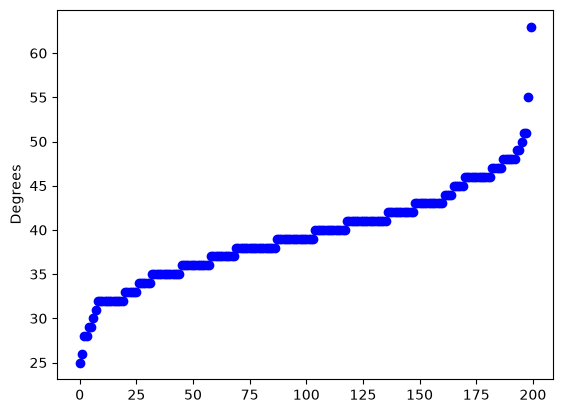

In [5]:
degs_sorted = np.sort(sum(A_ER))

plt.plot(range(len(degs_sorted)),degs_sorted,'bo')
plt.ylabel('Degrees')
plt.show()

### Task 4.2: Barabasi-Albert Graph [10 points]

In [6]:
# TODO: get the adj matrix A for BA graphs
A_BA = gen_BA(n,m,seed)
print(A_ER.shape)
print(A_ER.dtype)
print("edges ", A_ER.sum() // 2)

# save the matrix A into file
ssp.save_npz('../result/task_4_graph_BA.npz', ssp.csr_matrix(A_BA))

(200, 200)
int64
edges  3947


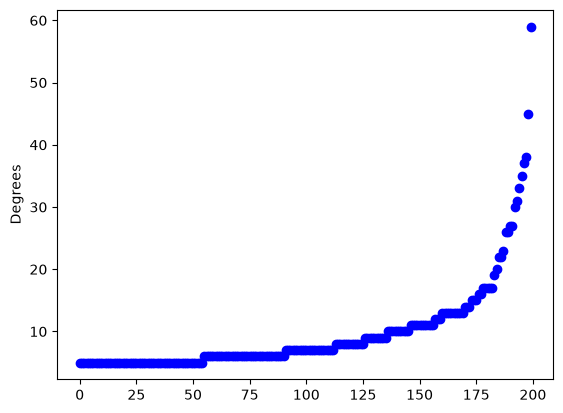

In [7]:
degs_sorted = np.sort(sum(A_BA))

plt.plot(range(len(degs_sorted)),degs_sorted,'bo')
plt.ylabel('Degrees')
plt.show()

## Task 5: Influence Maximization and Blocking [30 points]

In [2]:
# parameters: DO NOT CHANGE
p = 0.05
mc = 1000
#k=10
k = 5

In [3]:
from task_5 import greedySearch, modify_graph

In [4]:
graph = Graph(ssp.load_npz('../data/BA_graph_100.npz'))

In [6]:
seeds, influence = greedySearch(graph,k,p,mc)
print(seeds)
print(influence)

[1, np.int64(4), np.int64(3), np.int64(5), np.int64(19)]
[0.0, 3.514, 6.218, 8.313, 10.248, 11.716]


In [25]:
# super node checker 3000
degs = graph.get_deg_seq()
print(degs[3])
print(degs.max())
print(degs.mean())

27
33
5.82


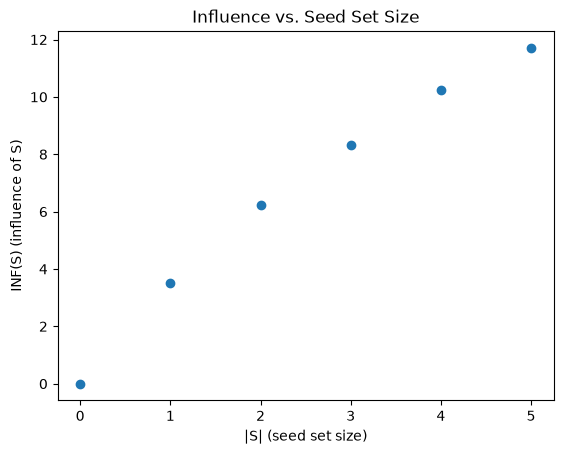

In [29]:
# super plotter 2000
x = list(range(len(influence)))
y = influence
plt.plot(x, y,'o')
plt.xlabel('|S| (seed set size)')
plt.ylabel('INF(S) (influence of S)')
plt.title('Influence vs. Seed Set Size')
plt.show()

In [23]:
# we recommend saving the results into files
np.savetxt('../result/IM_seeds.txt', seeds, fmt = '%s')
np.savetxt('../result/IM_influence.txt', influence, fmt = '%f')

# uncomment these lines if you want to read the values instead of recalculating them 
# seeds = np.loadtxt('../result/IM_seeds.txt', dtype = int)
# influence = np.loadtxt('../result/IM_influence.txt', dtype = float)

In [ ]:
# randomly select nn nodes; DO NOT CHANGE nn=50 BELOW
#nn=50
nn=50
np.random.seed(15)
target_nodes = np.random.choice(range(graph.n), nn, replace = False)

# each node in seed_set will randomly block a neighbor 
# equivalently, delete the edge between that node and the neighbor

# create a modified graph
graph_new = Graph(modify_graph(graph,target_nodes))

# TODO: compute the seeds and influences over the new graph using the same parameters
seeds_new, influence_new = greedySearch(graph_new,k,p,mc)
print(seeds_new)
print(influence_new)

np.savetxt('../result/IM_seeds_new.txt', seeds_new, fmt = '%s')
np.savetxt('../result/IM_influence_new.txt', influence_new, fmt = '%f')

# uncomment these lines if you want to read the values instead of recalculating them 
# seeds_new = np.loadtxt('../result/IM_seeds_new.txt', dtype = int)
# influence_new = np.loadtxt('../result/IM_influence_new.txt', dtype = float)

[1, np.int64(4), np.int64(3), np.int64(13), np.int64(5)]
[0.0, 3.076, 5.571, 7.574, 9.187, 10.704]


NameError: name 'influence' is not defined

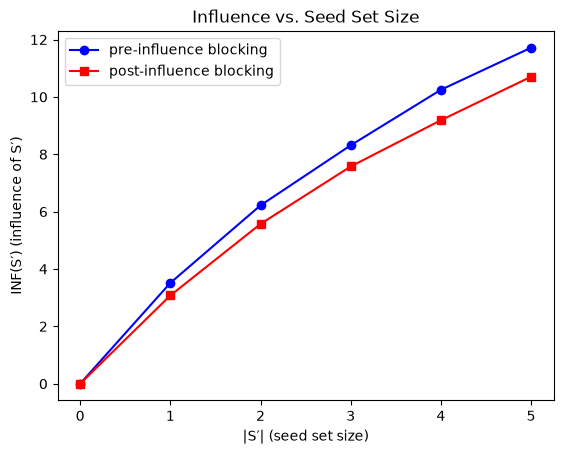

In [12]:
# plot in the same figure
plt.plot(range(k+1), influence,'-bo', label="pre-influence blocking")
plt.plot(range(k+1), influence_new,'-rs', label="post-influence blocking")
plt.xlabel('|S′| (seed set size)')
plt.ylabel('INF(S′) (influence of S′)')
plt.title('Influence vs. Seed Set Size')
plt.legend()
plt.show()